<a href="https://colab.research.google.com/github/latharaji20002010-glitch/Washington-State-EV-Market-Transaction-Analysis-2023-2026/blob/main/Washington_State_EV_Market_%26_Transaction_Analysis_%E2%80%94_2023%E2%80%932026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

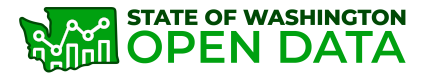

# ***Washington State EV Market & Transaction Analysis — 2023–2026***

##**Problem Statement**

This project analyzes Washington State electric vehicle title and registration transaction data from 2023–2026 to understand how the EV market is evolving. The analysis focuses on identifying the most active manufacturers and models, examining new versus used vehicle transactions, analyzing sale price and electric range patterns, evaluating transaction trends over time, and understanding geographic differences in EV activity across Washington State.  The goal is to transform raw transaction data into meaningful business insights using Python for data cleaning and exploratory analysis, SQL for structured querying and analysis, and Power BI for interactive visualization and reporting.


##**Project Objectives**

- Analyze EV transaction trends over time.
- Identify the most popular manufacturers and models.
- Compare new and used EV transactions.
- Analyze average sale prices and electric ranges.
- Identify counties with the highest EV activity.
- Understand common transaction types.
- Create an interactive dashboard using Looker Studio.

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv("Raw_Data_Electric_Vehicle_Population_Data_20261006.csv")
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 GEOID
0,1N4AZ1CP3K,King,Shoreline,WA,98155.0,2019,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,150.0,32.0,168526641,POINT (-122.30304 47.75494),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303302e+10
1,WBY8P4C51K,King,Kirkland,WA,98033.0,2019,BMW,I3,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,126.0,48.0,9418181,POINT (-122.2066 47.67887),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
2,3FA6P0SU8G,Snohomish,Lynnwood,WA,98036.0,2016,FORD,FUSION,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,19.0,1.0,172853495,POINT (-122.29245 47.82557),PUGET SOUND ENERGY INC,5.306105e+10
3,5YJ3E1EB3N,Yakima,Wapato,WA,98951.0,2022,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,15.0,204768175,POINT (-120.42083 46.44779),PACIFICORP,5.307794e+10
4,WBY1Z2C53F,King,Renton,WA,98055.0,2015,BMW,I3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,81.0,11.0,269262920,POINT (-122.19488 47.44034),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10


In [11]:
df.tail()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 GEOID
299700,ZACPDFDW7R,Kitsap,Port Orchard,WA,98312.0,2024,DODGE,HORNET,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,32.0,26.0,278485665,POINT (-122.65223 47.57192),PUGET SOUND ENERGY INC,5.303509e+10
299701,KM8KMDAF3P,Grant,Ephrata,WA,98823.0,2023,HYUNDAI,IONIQ 5,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,13.0,223872596,POINT (-119.55096 47.31909),PUD NO 2 OF GRANT COUNTY,5.302501e+10
299702,1GT10BDD5S,Kitsap,Poulsbo,WA,98370.0,2025,GMC,HUMMER EV PICKUP,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,23.0,280685807,POINT (-122.64681 47.73689),PUGET SOUND ENERGY INC,5.303509e+10
299703,5YJ3E1EB8N,Snohomish,Everett,WA,98208.0,2022,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,44.0,214860208,POINT (-122.22478 47.91564),PUGET SOUND ENERGY INC,5.306104e+10
299704,JM3KKCHA9T,King,Duvall,WA,98019.0,2026,MAZDA,CX-90,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,27.0,45.0,292954399,POINT (-121.98609 47.74068),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299705 entries, 0 to 299704
Data columns (total 16 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         299705 non-null  object 
 1   County                                             299694 non-null  object 
 2   City                                               299694 non-null  object 
 3   State                                              299705 non-null  object 
 4   Postal Code                                        299694 non-null  float64
 5   Model Year                                         299705 non-null  int64  
 6   Make                                               299705 non-null  object 
 7   Model                                              299705 non-null  object 
 8   Electric Vehicle Type                              299705 non-null  object

In [13]:
df.describe()

,Postal Code,Model Year,Electric Range,Legislative District,DOL Vehicle ID,2020 GEOID
count,299694.000000,299705.000000,299679.000000,298915.000000,2.997050e+05,2.996940e+05
mean,98176.001962,2022.344666,36.663313,28.754589,2.509924e+08,5.296742e+10
std,2652.053836,3.093007,76.034423,14.892388,6.238702e+07,1.687605e+09
min,1030.000000,1999.000000,0.000000,1.000000,4.469000e+03,1.001020e+09
25%,98052.000000,2021.000000,0.000000,17.000000,2.283017e+08,5.303301e+10
50%,98134.000000,2023.000000,0.000000,32.000000,2.679271e+08,5.303303e+10
75%,98391.000000,2024.000000,32.000000,42.000000,2.845359e+08,5.305394e+10
max,99801.000000,2027.000000,337.000000,49.000000,4.791150e+08,6.601095e+10
